In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

In [2]:
# New One
def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    return value


def weighted_cness(G, W):
    edges = list(G.edges())
    w_closeness = []
    for i in range(0, len(edges)):
        closeness = []
        nd_1 = edges[i][0]
        nd_2 = edges[i][1]
        weight_1 = weight_of_a_node(G,nd_1,W)
        weight_2 = weight_of_a_node(G,nd_2,W)
        edge_w = G.get_edge_data(nd_1, nd_2)
        val = edge_w['weight']
        influence_edge_val = (weight_1 + weight_2) * (val/W)
        closeness.append(edges[i])
        closeness.append(influence_edge_val)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_

def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### lw_1

Name: 
Type: Graph
Number of nodes: 14
Number of edges: 25
Average degree:   3.5714


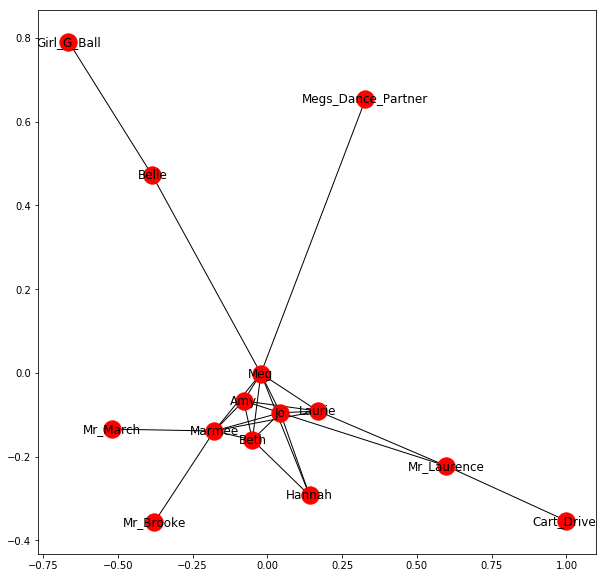

[[('Beth', 'Marmee'), 0.0831114186851211], [('Beth', 'Jo'), 0.1529190311418685], [('Beth', 'Amy'), 0.11081522491349481], [('Beth', 'Meg'), 0.11121384083044983], [('Beth', 'Hannah'), 0.008669896193771625], [('Marmee', 'Amy'), 0.11598615916955017], [('Marmee', 'Jo'), 0.06984083044982699], [('Marmee', 'Meg'), 0.08846505190311418], [('Marmee', 'Mr_March'), 0.020035986159169548], [('Marmee', 'Laurie'), 0.01857993079584775], [('Marmee', 'Mr_Brooke'), 0.02862283737024221], [('Jo', 'Amy'), 0.19089826989619377], [('Jo', 'Meg'), 0.30372318339100346], [('Jo', 'Hannah'), 0.03936332179930796], [('Jo', 'Laurie'), 0.2750339100346021], [('Jo', 'Mr_Laurence'), 0.0036871972318339094], [('Amy', 'Meg'), 0.18624221453287196], [('Amy', 'Laurie'), 0.0046449826989619376], [('Meg', 'Hannah'), 0.021868512110726643], [('Meg', 'Belle'), 0.009815916955017302], [('Meg', 'Megs_Dance_Partner'), 0.0032553633217993075], [('Meg', 'Laurie'), 0.04195432525951557], [('Mr_Laurence', 'Laurie'), 0.014704498269896194], [('Mr_L

In [4]:
lw_1 = nx.read_weighted_edgelist('lw_m_1.txt', delimiter=',')
print(nx.info(lw_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_1)
plt.show()

total_edge_weight = total_weight_of_G(lw_1) #NCF
w_ncf_1 = weighted_cness(lw_1,total_edge_weight)
print(w_ncf_1)

In [5]:
edge_w = list(w_ncf_1)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0               (Beth, Marmee)  0.145579
1                   (Beth, Jo)  0.267855
2                  (Beth, Amy)  0.194105
3                  (Beth, Meg)  0.194804
4               (Beth, Hannah)  0.015186
5                (Marmee, Amy)  0.203163
6                 (Marmee, Jo)  0.122334
7                (Marmee, Meg)  0.154956
8           (Marmee, Mr_March)  0.035095
9             (Marmee, Laurie)  0.032545
10         (Marmee, Mr_Brooke)  0.050136
11                   (Jo, Amy)  0.334380
12                   (Jo, Meg)  0.532005
13                (Jo, Hannah)  0.068949
14                (Jo, Laurie)  0.481753
15           (Jo, Mr_Laurence)  0.006459
16                  (Amy, Meg)  0.326224
17               (Amy, Laurie)  0.008136
18               (Meg, Hannah)  0.038305
19                (Meg, Belle)  0.017194
20   (Meg, Megs_Dance_Partner)  0.005702
21               (Meg, Laurie)  0.073488
22       (Mr_Laurence, Laurie)  0.025757
23  (Mr_Laurence

### lw_2

Name: 
Type: Graph
Number of nodes: 20
Number of edges: 41
Average degree:   4.1000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


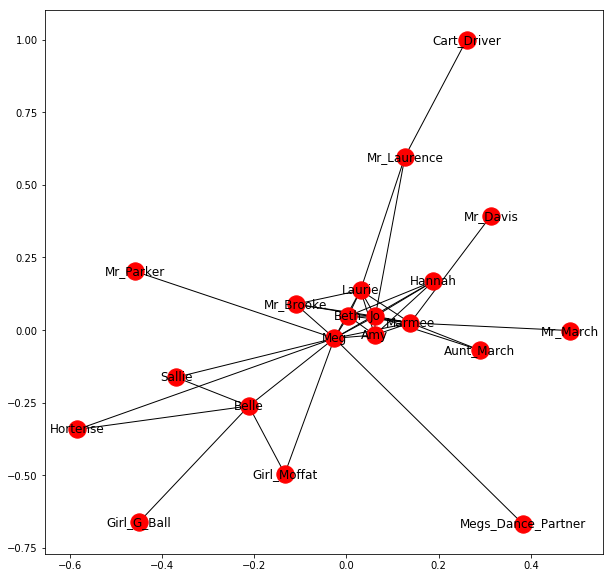

[[('Beth', 'Marmee'), 0.050151433207138996], [('Beth', 'Jo'), 0.13734451054624122], [('Beth', 'Amy'), 0.0706679286100595], [('Beth', 'Meg'), 0.05976203353163872], [('Beth', 'Hannah'), 0.004429421308815576], [('Beth', 'Laurie'), 0.011418334234721472], [('Marmee', 'Amy'), 0.09346403461330449], [('Marmee', 'Jo'), 0.12361005949161712], [('Marmee', 'Meg'), 0.09653866955110871], [('Marmee', 'Mr_March'), 0.009871552190373176], [('Marmee', 'Laurie'), 0.009134667387777178], [('Marmee', 'Mr_Brooke'), 0.02230935640886966], [('Marmee', 'Mr_Davis'), 0.005640886965927528], [('Marmee', 'Aunt_March'), 0.031195240670632778], [('Jo', 'Amy'), 0.3044469983775014], [('Jo', 'Meg'), 0.2377244456462953], [('Jo', 'Hannah'), 0.02224175229853975], [('Jo', 'Laurie'), 0.17657111952406704], [('Jo', 'Mr_Laurence'), 0.0018523526230394807], [('Jo', 'Aunt_March'), 0.011755002704164413], [('Jo', 'Mr_Brooke'), 0.011202001081665766], [('Jo', 'Jo'), 0.009194159004867496], [('Amy', 'Meg'), 0.16319632233639805], [('Amy', 'La

In [6]:
lw_2 = nx.read_weighted_edgelist('lw_m_2.txt', delimiter=',')
print(nx.info(lw_2))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_2)
plt.show()

total_edge_weight = total_weight_of_G(lw_2) #NCF
w_ncf_2 = weighted_cness(lw_2,total_edge_weight)
print(w_ncf_2)

In [7]:
edge_w = list(w_ncf_2)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0               (Beth, Marmee)  0.094065
1                   (Beth, Jo)  0.257606
2                  (Beth, Amy)  0.132546
3                  (Beth, Meg)  0.112091
4               (Beth, Hannah)  0.008308
5               (Beth, Laurie)  0.021416
6                (Marmee, Amy)  0.175303
7                 (Marmee, Jo)  0.231845
8                (Marmee, Meg)  0.181070
9           (Marmee, Mr_March)  0.018515
10            (Marmee, Laurie)  0.017133
11         (Marmee, Mr_Brooke)  0.041844
12          (Marmee, Mr_Davis)  0.010580
13        (Marmee, Aunt_March)  0.058510
14                   (Jo, Amy)  0.571026
15                   (Jo, Meg)  0.445880
16                (Jo, Hannah)  0.041717
17                (Jo, Laurie)  0.331180
18           (Jo, Mr_Laurence)  0.003474
19            (Jo, Aunt_March)  0.022048
20             (Jo, Mr_Brooke)  0.021011
21                    (Jo, Jo)  0.017245
22                  (Amy, Meg)  0.306094
23              

### lw_3

Name: 
Type: Graph
Number of nodes: 20
Number of edges: 42
Average degree:   4.2000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


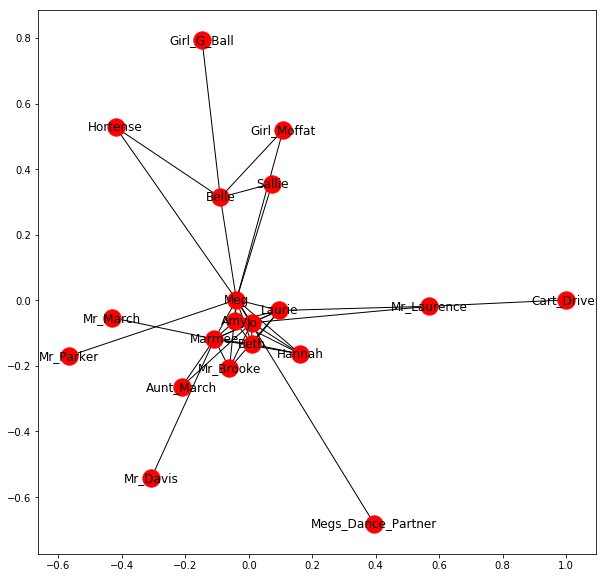

[[('Beth', 'Marmee'), 0.055709783913565424], [('Beth', 'Jo'), 0.13268836946543322], [('Beth', 'Amy'), 0.06808973589435774], [('Beth', 'Meg'), 0.05404808982416496], [('Beth', 'Hannah'), 0.004111203304851352], [('Beth', 'Laurie'), 0.010333177388602502], [('Marmee', 'Amy'), 0.09078631452581032], [('Marmee', 'Jo'), 0.13268836946543322], [('Marmee', 'Meg'), 0.11017495233387474], [('Marmee', 'Mr_March'), 0.009106216015818092], [('Marmee', 'Laurie'), 0.0144664483440435], [('Marmee', 'Mr_Brooke'), 0.0403617329284655], [('Marmee', 'Mr_Davis'), 0.0052035520090389096], [('Marmee', 'Aunt_March'), 0.028529058682296445], [('Marmee', 'Hannah'), 0.004111203304851352], [('Jo', 'Amy'), 0.284036040886943], [('Jo', 'Meg'), 0.22975734411411625], [('Jo', 'Hannah'), 0.024786385142292214], [('Jo', 'Laurie'), 0.1993503283666408], [('Jo', 'Mr_Laurence'), 0.0016716245321658075], [('Jo', 'Aunt_March'), 0.010757979662453218], [('Jo', 'Mr_Brooke'), 0.010140085445943085], [('Jo', 'Jo'), 0.012499117293976415], [('Amy

In [8]:
lw_3 = nx.read_weighted_edgelist('lw_m_3.txt', delimiter=',')
print(nx.info(lw_3))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_3)
plt.show()

total_edge_weight = total_weight_of_G(lw_3) #NCF
w_ncf_3 = weighted_cness(lw_3,total_edge_weight)
print(w_ncf_3)

In [9]:
edge_w = list(w_ncf_3)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0               (Beth, Marmee)  0.106115
1                   (Beth, Jo)  0.252743
2                  (Beth, Amy)  0.129696
3                  (Beth, Meg)  0.102950
4               (Beth, Hannah)  0.007831
5               (Beth, Laurie)  0.019682
6                (Marmee, Amy)  0.172928
7                 (Marmee, Jo)  0.252743
8                (Marmee, Meg)  0.209860
9           (Marmee, Mr_March)  0.017345
10            (Marmee, Laurie)  0.027555
11         (Marmee, Mr_Brooke)  0.076880
12          (Marmee, Mr_Davis)  0.009912
13        (Marmee, Aunt_March)  0.054342
14            (Marmee, Hannah)  0.007831
15                   (Jo, Amy)  0.541028
16                   (Jo, Meg)  0.437638
17                (Jo, Hannah)  0.047213
18                (Jo, Laurie)  0.379719
19           (Jo, Mr_Laurence)  0.003184
20            (Jo, Aunt_March)  0.020492
21             (Jo, Mr_Brooke)  0.019315
22                    (Jo, Jo)  0.023808
23              

### lw_4

Name: 
Type: Graph
Number of nodes: 23
Number of edges: 48
Average degree:   4.1739


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


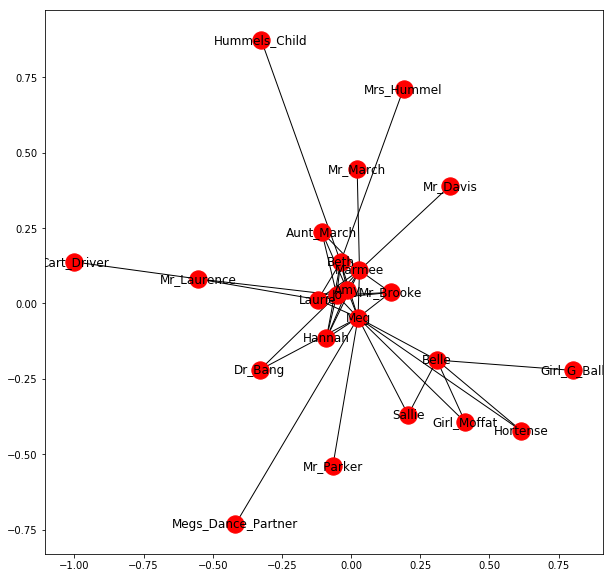

[[('Beth', 'Marmee'), 0.060369190586089194], [('Beth', 'Jo'), 0.13785049957850223], [('Beth', 'Amy'), 0.06411862052763229], [('Beth', 'Meg'), 0.04971946214120867], [('Beth', 'Hannah'), 0.0036466466743135116], [('Beth', 'Laurie'), 0.009159802932518899], [('Beth', 'Hummels_Child'), 0.0010701551940962672], [('Beth', 'Mrs_Hummel'), 0.0021403103881925344], [('Marmee', 'Amy'), 0.0806062658061663], [('Marmee', 'Jo'), 0.12498445295117534], [('Marmee', 'Meg'), 0.10128038584320283], [('Marmee', 'Mr_March'), 0.007950588023935544], [('Marmee', 'Laurie'), 0.012823724105526457], [('Marmee', 'Mr_Brooke'), 0.03555091831235058], [('Marmee', 'Mr_Davis'), 0.004543193156534597], [('Marmee', 'Aunt_March'), 0.027183151144953774], [('Marmee', 'Hannah'), 0.0036466466743135116], [('Jo', 'Amy'), 0.263205490526665], [('Jo', 'Meg'), 0.24606314174762645], [('Jo', 'Hannah'), 0.025647448211052915], [('Jo', 'Laurie'), 0.18221918574922957], [('Jo', 'Mr_Laurence'), 0.002966031425768024], [('Jo', 'Aunt_March'), 0.010245

In [10]:
lw_4 = nx.read_weighted_edgelist('lw_m_4.txt', delimiter=',')
print(nx.info(lw_4))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_4)
plt.show()

total_edge_weight = total_weight_of_G(lw_4) #NCF
w_ncf_4 = weighted_cness(lw_4,total_edge_weight)
print(w_ncf_4)

In [11]:
edge_w = list(w_ncf_4)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0               (Beth, Marmee)  0.117874
1                   (Beth, Jo)  0.269161
2                  (Beth, Amy)  0.125195
3                  (Beth, Meg)  0.097080
4               (Beth, Hannah)  0.007120
5               (Beth, Laurie)  0.017885
6        (Beth, Hummels_Child)  0.002090
7           (Beth, Mrs_Hummel)  0.004179
8                (Marmee, Amy)  0.157388
9                 (Marmee, Jo)  0.244039
10               (Marmee, Meg)  0.197756
11          (Marmee, Mr_March)  0.015524
12            (Marmee, Laurie)  0.025039
13         (Marmee, Mr_Brooke)  0.069415
14          (Marmee, Mr_Davis)  0.008871
15        (Marmee, Aunt_March)  0.053077
16            (Marmee, Hannah)  0.007120
17                   (Jo, Amy)  0.513924
18                   (Jo, Meg)  0.480452
19                (Jo, Hannah)  0.050078
20                (Jo, Laurie)  0.355793
21           (Jo, Mr_Laurence)  0.005791
22            (Jo, Aunt_March)  0.020005
23             (

### lw_5

Name: 
Type: Graph
Number of nodes: 25
Number of edges: 72
Average degree:   5.7600


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


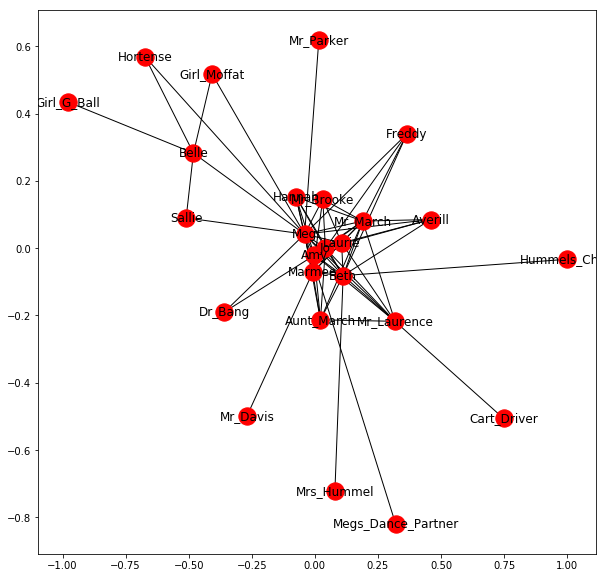

[[('Beth', 'Marmee'), 0.055751316210637857], [('Beth', 'Jo'), 0.12514486595070695], [('Beth', 'Amy'), 0.06411146124214963], [('Beth', 'Meg'), 0.04624121146565711], [('Beth', 'Hannah'), 0.004892330106731713], [('Beth', 'Laurie'), 0.01805995518813258], [('Beth', 'Hummels_Child'), 0.0009692221940155187], [('Beth', 'Mrs_Hummel'), 0.0019384443880310373], [('Beth', 'Mr_Laurence'), 0.014614904912749308], [('Beth', 'Freddy'), 0.0015273010231675148], [('Beth', 'Averill'), 0.0015597234026114503], [('Beth', 'Aunt_March'), 0.006547940971953952], [('Beth', 'Mr_March'), 0.009850884648072317], [('Marmee', 'Amy'), 0.07223982075253033], [('Marmee', 'Jo'), 0.13485502367523539], [('Marmee', 'Meg'), 0.10721115109104756], [('Marmee', 'Mr_March'), 0.018037190538735776], [('Marmee', 'Laurie'), 0.011478212161013676], [('Marmee', 'Mr_Brooke'), 0.03153938698248364], [('Marmee', 'Mr_Davis'), 0.004067284025562632], [('Marmee', 'Aunt_March'), 0.029428483129325285], [('Marmee', 'Hannah'), 0.0032574143773247536], [(

In [12]:
lw_5 = nx.read_weighted_edgelist('lw_m_5.txt', delimiter=',')
print(nx.info(lw_5))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_5)
plt.show()

total_edge_weight = total_weight_of_G(lw_5) #NCF
w_ncf_5 = weighted_cness(lw_5,total_edge_weight)
print(w_ncf_5)

In [13]:
edge_w = list(w_ncf_5)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0               (Beth, Marmee)  0.114649
1                   (Beth, Jo)  0.257353
2                  (Beth, Amy)  0.131842
3                  (Beth, Meg)  0.095092
4               (Beth, Hannah)  0.010061
5               (Beth, Laurie)  0.037139
6        (Beth, Hummels_Child)  0.001993
7           (Beth, Mrs_Hummel)  0.003986
8          (Beth, Mr_Laurence)  0.030055
9               (Beth, Freddy)  0.003141
10             (Beth, Averill)  0.003207
11          (Beth, Aunt_March)  0.013465
12            (Beth, Mr_March)  0.020258
13               (Marmee, Amy)  0.148557
14                (Marmee, Jo)  0.277322
15               (Marmee, Meg)  0.220474
16          (Marmee, Mr_March)  0.037092
17            (Marmee, Laurie)  0.023604
18         (Marmee, Mr_Brooke)  0.064859
19          (Marmee, Mr_Davis)  0.008364
20        (Marmee, Aunt_March)  0.060518
21            (Marmee, Hannah)  0.006699
22                   (Jo, Amy)  0.488230
23              

### lw_6

Name: 
Type: Graph
Number of nodes: 26
Number of edges: 73
Average degree:   5.6154


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


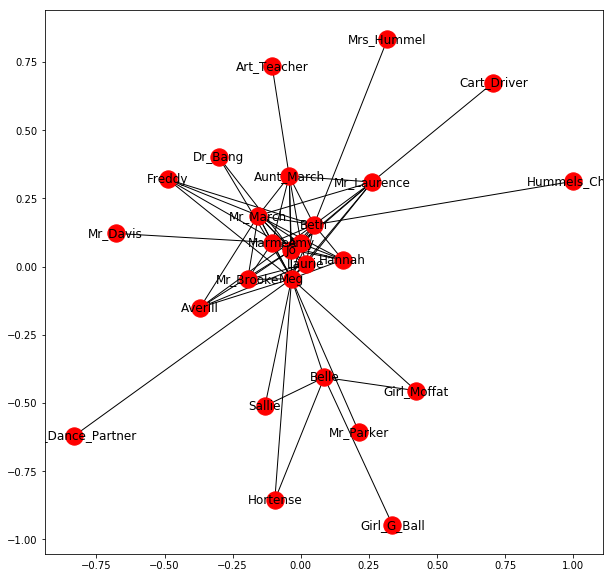

[[('Beth', 'Marmee'), 0.050607172666569895], [('Beth', 'Jo'), 0.11504697252866888], [('Beth', 'Amy'), 0.06564133038176803], [('Beth', 'Meg'), 0.041946400058063577], [('Beth', 'Hannah'), 0.004429616054579764], [('Beth', 'Laurie'), 0.016341722310930472], [('Beth', 'Hummels_Child'), 0.0008703866671505299], [('Beth', 'Mrs_Hummel'), 0.0017407733343010599], [('Beth', 'Mr_Laurence'), 0.013278641675134272], [('Beth', 'Freddy'), 0.0013914846131514009], [('Beth', 'Averill'), 0.001418134888953404], [('Beth', 'Aunt_March'), 0.005944712585280883], [('Beth', 'Mr_March'), 0.008940884017999709], [('Marmee', 'Amy'), 0.06556648279866455], [('Marmee', 'Jo'), 0.1492415444912179], [('Marmee', 'Meg'), 0.0972650012701408], [('Marmee', 'Mr_March'), 0.016372908803890262], [('Marmee', 'Laurie'), 0.010387370264189287], [('Marmee', 'Mr_Brooke'), 0.02858950863695747], [('Marmee', 'Mr_Davis'), 0.0036652634634925245], [('Marmee', 'Aunt_March'), 0.026720587167948902], [('Marmee', 'Hannah'), 0.002949675206851502], [('

In [14]:
lw_6 = nx.read_weighted_edgelist('lw_m_6.txt', delimiter=',')
print(nx.info(lw_6))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_6)
plt.show()

total_edge_weight = total_weight_of_G(lw_6) #NCF
w_ncf_6 = weighted_cness(lw_6,total_edge_weight)
print(w_ncf_6)

In [15]:
edge_w = list(w_ncf_6)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0               (Beth, Marmee)  0.100485
1                   (Beth, Jo)  0.228436
2                  (Beth, Amy)  0.130337
3                  (Beth, Meg)  0.083288
4               (Beth, Hannah)  0.008795
5               (Beth, Laurie)  0.032448
6        (Beth, Hummels_Child)  0.001728
7           (Beth, Mrs_Hummel)  0.003456
8          (Beth, Mr_Laurence)  0.026366
9               (Beth, Freddy)  0.002763
10             (Beth, Averill)  0.002816
11          (Beth, Aunt_March)  0.011804
12            (Beth, Mr_March)  0.017753
13               (Marmee, Amy)  0.130188
14                (Marmee, Jo)  0.296333
15               (Marmee, Meg)  0.193129
16          (Marmee, Mr_March)  0.032510
17            (Marmee, Laurie)  0.020625
18         (Marmee, Mr_Brooke)  0.056767
19          (Marmee, Mr_Davis)  0.007278
20        (Marmee, Aunt_March)  0.053056
21            (Marmee, Hannah)  0.005857
22                   (Jo, Amy)  0.484124
23              

### lw_7

Name: 
Type: Graph
Number of nodes: 36
Number of edges: 83
Average degree:   4.6111


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


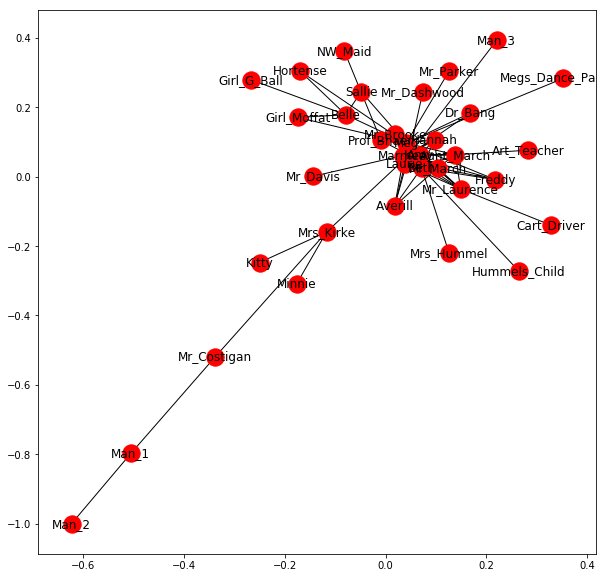

[[('Beth', 'Marmee'), 0.04666866746698679], [('Beth', 'Jo'), 0.12307864322199469], [('Beth', 'Amy'), 0.06052420968387355], [('Beth', 'Meg'), 0.03866644697094524], [('Beth', 'Hannah'), 0.004086928889202739], [('Beth', 'Laurie'), 0.015071714960494002], [('Beth', 'Hummels_Child'), 0.0008013009125218714], [('Beth', 'Mrs_Hummel'), 0.001602601825043743], [('Beth', 'Mr_Laurence'), 0.01225195960737236], [('Beth', 'Freddy'), 0.0012887507944354213], [('Beth', 'Averill'), 0.00131179922949572], [('Beth', 'Aunt_March'), 0.00548258519093912], [('Beth', 'Mr_March'), 0.008244474260292352], [('Marmee', 'Amy'), 0.06045947790881059], [('Marmee', 'Jo'), 0.13814349269119414], [('Marmee', 'Meg'), 0.08966576826809156], [('Marmee', 'Mr_March'), 0.015098686533436904], [('Marmee', 'Laurie'), 0.009580793101554347], [('Marmee', 'Mr_Brooke'), 0.0264321414840446], [('Marmee', 'Mr_Davis'), 0.003340551907037325], [('Marmee', 'Aunt_March'), 0.024645152178518467], [('Marmee', 'Hannah'), 0.0027216769060565403], [('Jo', 

In [16]:
lw_7 = nx.read_weighted_edgelist('lw_m_7.txt', delimiter=',')
print(nx.info(lw_7))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_7)
plt.show()

total_edge_weight = total_weight_of_G(lw_7) #NCF
w_ncf_7 = weighted_cness(lw_7,total_edge_weight)
print(w_ncf_7)

In [17]:
edge_w = list(w_ncf_7)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0               (Beth, Marmee)  0.098253
1                   (Beth, Jo)  0.259121
2                  (Beth, Amy)  0.127423
3                  (Beth, Meg)  0.081406
4               (Beth, Hannah)  0.008604
5               (Beth, Laurie)  0.031731
6        (Beth, Hummels_Child)  0.001687
7           (Beth, Mrs_Hummel)  0.003374
8          (Beth, Mr_Laurence)  0.025794
9               (Beth, Freddy)  0.002713
10             (Beth, Averill)  0.002762
11          (Beth, Aunt_March)  0.011543
12            (Beth, Mr_March)  0.017357
13               (Marmee, Amy)  0.127287
14                (Marmee, Jo)  0.290838
15               (Marmee, Meg)  0.188776
16          (Marmee, Mr_March)  0.031788
17            (Marmee, Laurie)  0.020171
18         (Marmee, Mr_Brooke)  0.055648
19          (Marmee, Mr_Davis)  0.007033
20        (Marmee, Aunt_March)  0.051886
21            (Marmee, Hannah)  0.005730
22                   (Jo, Amy)  0.475075
23              

### lw_8

Name: 
Type: Graph
Number of nodes: 42
Number of edges: 100
Average degree:   4.7619


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


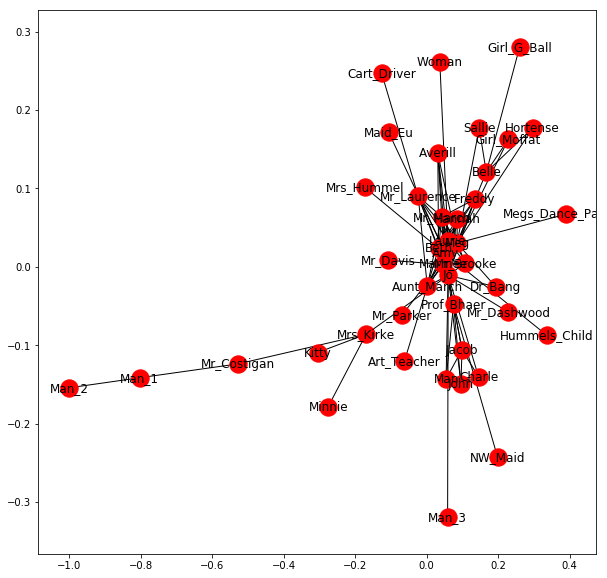

[[('Beth', 'Marmee'), 0.039908536585365854], [('Beth', 'Jo'), 0.10625334622248662], [('Beth', 'Amy'), 0.05174449732302201], [('Beth', 'Meg'), 0.033042831647828674], [('Beth', 'Hannah'), 0.003485648423557406], [('Beth', 'Laurie'), 0.01292385484830458], [('Beth', 'Hummels_Child'), 0.0006740779298036883], [('Beth', 'Mrs_Hummel'), 0.0013481558596073766], [('Beth', 'Mr_Laurence'), 0.010487061273051754], [('Beth', 'Freddy'), 0.001125817965496728], [('Beth', 'Averill'), 0.001125817965496728], [('Beth', 'Aunt_March'), 0.004699583581201665], [('Beth', 'Mr_March'), 0.007049375371802499], [('Marmee', 'Amy'), 0.05169541939321832], [('Marmee', 'Jo'), 0.11927424152290303], [('Marmee', 'Meg'), 0.07663407198096371], [('Marmee', 'Mr_March'), 0.012911585365853658], [('Marmee', 'Laurie'), 0.008216463414634147], [('Marmee', 'Mr_Brooke'), 0.02266508030933968], [('Marmee', 'Mr_Davis'), 0.002798929208804283], [('Marmee', 'Aunt_March'), 0.021128048780487803], [('Marmee', 'Hannah'), 0.0023215348007138608], [('

In [18]:
lw_8 = nx.read_weighted_edgelist('lw_m_8.txt', delimiter=',')
print(nx.info(lw_8))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_8)
plt.show()

total_edge_weight = total_weight_of_G(lw_8) #NCF
w_ncf_8 = weighted_cness(lw_8,total_edge_weight)
print(w_ncf_8)

In [19]:
edge_w = list(w_ncf_8)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0               (Beth, Marmee)  0.090880
1                   (Beth, Jo)  0.241960
2                  (Beth, Amy)  0.117832
3                  (Beth, Meg)  0.075245
4               (Beth, Hannah)  0.007938
5               (Beth, Laurie)  0.029430
6        (Beth, Hummels_Child)  0.001535
7           (Beth, Mrs_Hummel)  0.003070
8          (Beth, Mr_Laurence)  0.023881
9               (Beth, Freddy)  0.002564
10             (Beth, Averill)  0.002564
11          (Beth, Aunt_March)  0.010702
12            (Beth, Mr_March)  0.016053
13               (Marmee, Amy)  0.117721
14                (Marmee, Jo)  0.271611
15               (Marmee, Meg)  0.174511
16          (Marmee, Mr_March)  0.029402
17            (Marmee, Laurie)  0.018711
18         (Marmee, Mr_Brooke)  0.051613
19          (Marmee, Mr_Davis)  0.006374
20        (Marmee, Aunt_March)  0.048113
21            (Marmee, Hannah)  0.005287
22                   (Jo, Amy)  0.443554
23              

### lw_9

Name: 
Type: Graph
Number of nodes: 44
Number of edges: 105
Average degree:   4.7727


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


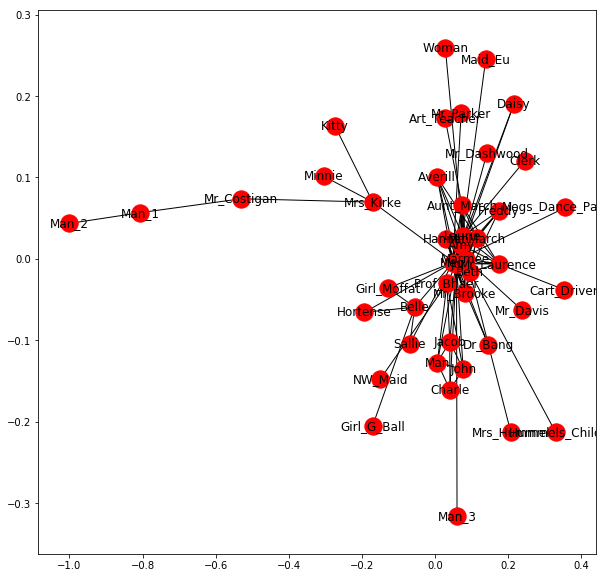

[[('Beth', 'Marmee'), 0.03573265244162405], [('Beth', 'Jo'), 0.12799174810232614], [('Beth', 'Amy'), 0.04628120241431737], [('Beth', 'Meg'), 0.029542548994904817], [('Beth', 'Hannah'), 0.0031219010757738883], [('Beth', 'Laurie'), 0.011560564025231309], [('Beth', 'Hummels_Child'), 0.0006033728097493244], [('Beth', 'Mrs_Hummel'), 0.0012067456194986487], [('Beth', 'Mr_Laurence'), 0.009455987862912517], [('Beth', 'Freddy'), 0.0010087685264219756], [('Beth', 'Averill'), 0.0010087685264219756], [('Beth', 'Aunt_March'), 0.004202661272405563], [('Beth', 'Mr_March'), 0.006305762195580714], [('Marmee', 'Amy'), 0.0525922754708152], [('Marmee', 'Jo'), 0.12265875859806255], [('Marmee', 'Meg'), 0.07174619041619741], [('Marmee', 'Mr_March'), 0.017866326220812027], [('Marmee', 'Laurie'), 0.008407682927440952], [('Marmee', 'Mr_Brooke'), 0.022485004931724457], [('Marmee', 'Mr_Davis'), 0.00250200558761578], [('Marmee', 'Aunt_March'), 0.018911975725825033], [('Marmee', 'Hannah'), 0.0020812673838492587], [

In [24]:
lw_9 = nx.read_weighted_edgelist('lw_m_9.txt', delimiter=',')
print(nx.info(lw_9))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_9)
plt.show()

total_edge_weight = total_weight_of_G(lw_9) #NCF
w_ncf_9 = weighted_cness(lw_9,total_edge_weight)
print(w_ncf_9)

In [25]:
edge_w = list(w_ncf_9)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()
df_2.to_csv('lw_mr_t9.csv')
print(df_2)

                          Edges        IF
0                (Beth, Marmee)  0.079172
1                    (Beth, Jo)  0.283589
2                   (Beth, Amy)  0.102544
3                   (Beth, Meg)  0.065457
4                (Beth, Hannah)  0.006917
5                (Beth, Laurie)  0.025615
6         (Beth, Hummels_Child)  0.001337
7            (Beth, Mrs_Hummel)  0.002674
8           (Beth, Mr_Laurence)  0.020951
9                (Beth, Freddy)  0.002235
10              (Beth, Averill)  0.002235
11           (Beth, Aunt_March)  0.009312
12             (Beth, Mr_March)  0.013972
13                (Marmee, Amy)  0.116528
14                 (Marmee, Jo)  0.271773
15                (Marmee, Meg)  0.158967
16           (Marmee, Mr_March)  0.039586
17             (Marmee, Laurie)  0.018629
18          (Marmee, Mr_Brooke)  0.049820
19           (Marmee, Mr_Davis)  0.005544
20         (Marmee, Aunt_March)  0.041903
21             (Marmee, Hannah)  0.004611
22        (Marmee, Mr_Laurence)  0